In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import torch

import gym
from gym import spaces
from PortfolioEnv2 import PortfolioEnv2

from stable_baselines3 import PPO, SAC
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize

In [12]:
data = pd.read_csv('all_sector_data-4-15.csv', parse_dates=['Date'], index_col='Date')
data.sort_index(inplace=True)

asset_cols = ['XLC', 'XLY', 'XLP', 'XLE', 'XLF', 'XLV', 'XLI', 'XLK', 'XLB', 'XLRE', 'XLU']
vol_cols = ['vol20', 'vol60', 'VIX']

In [13]:
#split into train/test
train_start = "2018-09-13"
train_end   = "2024-01-02"
test_start  = "2024-01-03"
test_end    = "2025-04-15"
train_data = data.loc[train_start:train_end]
test_data  = data.loc[test_start:test_end]

In [14]:
train_env = DummyVecEnv([lambda: PortfolioEnv2(train_data, asset_cols, vol_cols, lookback=60)])
vec_env = VecNormalize.load("ppo_vec_normalize_1000000.pkl", train_env)
model = PPO.load("ppo_model1000000.zip", env=vec_env)

/Users/krishshah/Desktop/Code/DRLPortfolioOptimization/venv/lib/python3.10/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


In [15]:
"""PPO Test Inference"""
lookback = 60

#Test data + data from 60 days before first test day for continuity
padded_test_data = pd.concat([train_data.iloc[-lookback:], test_data])

#Create a dummy vectorized environment for the test data using the PortfolioEnv.
raw_test_env = DummyVecEnv([lambda: PortfolioEnv2(padded_test_data, asset_cols, vol_cols, lookback=lookback)])

#Load the VecNormalize wrapper with stats from training
test_env = VecNormalize.load("ppo_vec_normalize.pkl", raw_test_env)

#Set to eval mode
test_env.training = False
test_env.norm_reward = False

#Reset and evaluate
obs = test_env.reset()
done = False
portfolio_history = []
date_history = []

while not done:
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, done, info = test_env.step(action)
    #print("Action:", action)

    if not done:
        current_step = test_env.get_attr('current_step')[0]
        current_date = padded_test_data.index[current_step]
        if current_date >= test_data.index[0]:
            portfolio_history.append(info[0]["portfolio_value"])
            date_history.append(current_date)
    
        PPO_weights = test_env.venv.envs[0].weights

/Users/krishshah/Desktop/Code/DRLPortfolioOptimization/venv/lib/python3.10/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


In [16]:
train_env = DummyVecEnv([lambda: PortfolioEnv2(train_data, asset_cols, vol_cols, lookback=60)])
vec_env = VecNormalize.load("vecnorm_sac_1000000.pkl", train_env)
sac_model = SAC.load("sac_model_1000000.zip", env=vec_env)

/Users/krishshah/Desktop/Code/DRLPortfolioOptimization/venv/lib/python3.10/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


In [17]:
"""SAC Test Inference"""

#Evaluate SAC model on padded test data
lookback = 60
padded_test_data_sac = pd.concat([train_data.iloc[-lookback:], test_data])
raw_sac_test_env = DummyVecEnv([lambda: PortfolioEnv2(padded_test_data_sac, asset_cols, vol_cols, lookback=lookback)])

#Wrap it using the same normalization stats as training
sac_test_env = VecNormalize.load("ppo_vec_normalize.pkl", raw_sac_test_env)
sac_test_env.training = False  # Turn off update of normalization stats
sac_test_env.norm_reward = False  # Return raw (true) rewards

obs = sac_test_env.reset()
done = False
sac_portfolio_history = []
sac_date_history = []

while not done:
    action, _ = sac_model.predict(obs, deterministic=True)
    #print(action)
    obs, reward, done, info = sac_test_env.step(action)
    if not done:
        current_date = padded_test_data_sac.index[sac_test_env.get_attr('current_step')[0]]
        if current_date >= test_data.index[0]:
            sac_portfolio_history.append(info[0]['portfolio_value'])  # info is a list of dicts
            sac_date_history.append(current_date)
    
        SAC_weights = sac_test_env.venv.envs[0].weights

/Users/krishshah/Desktop/Code/DRLPortfolioOptimization/venv/lib/python3.10/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


In [18]:
"""SPY Calculation and Purchase"""
#For portfolio evaluation later, assume we bought 100k worth of SPY on first day of test data
first_date = test_data.index[0]
first_spy_close = test_data.loc[first_date, "SPY"]

#Calculate the number of shares bought with $100k
shares = (100000 / first_spy_close) * .99

#Compute the daily portfolio value: shares multiplied by SPY close price
spy_portfolio_value = shares * test_data["SPY"]

In [19]:
"""MVO Calculation and Purchase"""
mvo_weights = {
    'XLP': 0.3586,
    'XLV': 0.1414,
    'XLK': 0.5000,
}

#Calculate shares for each ETF
initial_prices = test_data.loc[first_date, mvo_weights.keys()]
shares = {
    etf: (100000 * weight / initial_prices[etf]) * 0.99
    for etf, weight in mvo_weights.items()
}

#Compute portfolio value over time
mvo_portfolio_value = sum(shares[etf] * test_data[etf] for etf in mvo_weights)

In [20]:
"""Print all weights"""
spy_weights = {
    'XLC': 9.22,
    'XLY': 10.22,
    'XLP': 6.50,
    'XLE': 3.40,
    'XLF': 14.59,
    'XLV': 11.01,
    'XLI': 8.60,
    'XLK': 29.45,
    'XLB': 2.03,
    'XLRE': 2.32,
    'XLU': 2.66
}

mvo_weights = {
    'XLC': 0.00,
    'XLY': 0.00,
    'XLP': 35.86,
    'XLE': 0.00,
    'XLF': 0.00,
    'XLV': 14.14,
    'XLI': 0.00,
    'XLK': 50.00,
    'XLB': 0.00,
    'XLRE': 0.00,
    'XLU': 0.00
}

print(f"{'ETF':<10} {'PPO Weight':<12} {'SAC Weight':<12} {'MVO Weight':<12} {'SPY Weight':<12}")
print("-" * 60)
for i, etf in enumerate(asset_cols):
    ppo = PPO_weights[i]
    sac = SAC_weights[i]
    mvo = mvo_weights.get(etf, 0)
    spy = spy_weights.get(etf, 0)
    print(f"{etf:<10} {ppo*100:<12.4f} {sac*100:<12.4f} {mvo:<12.4f} {spy:<12.4f}")

ETF        PPO Weight   SAC Weight   MVO Weight   SPY Weight  
------------------------------------------------------------
XLC        0.0000       9.0183       0.0000       9.2200      
XLY        0.0000       9.0496       0.0000       10.2200     
XLP        45.4952      9.2764       35.8600      6.5000      
XLE        0.0000       8.6539       0.0000       3.4000      
XLF        0.0000       9.0689       0.0000       14.5900     
XLV        0.0000       9.1850       14.1400      11.0100     
XLI        0.0000       9.0705       0.0000       8.6000      
XLK        0.0000       9.0728       50.0000      29.4500     
XLB        0.0000       9.1665       0.0000       2.0300      
XLRE       0.0000       9.1315       0.0000       2.3200      
XLU        54.5048      9.3066       0.0000       2.6600      


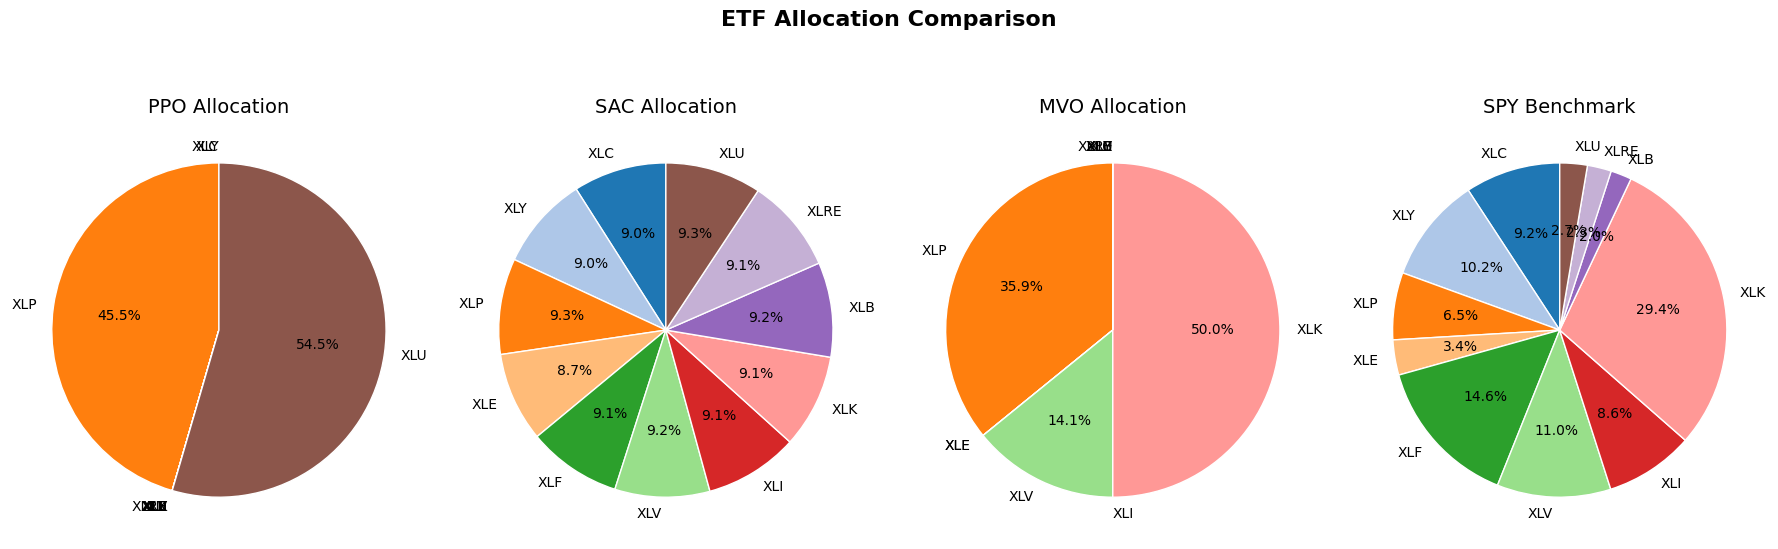

In [21]:
"""Pie Chart"""
ppo_weights_pct = [w * 100 for w in PPO_weights]
sac_weights_pct = [w * 100 for w in SAC_weights]
spy_weights_pct = [spy_weights.get(etf, 0) for etf in asset_cols]
mvo_weights_pct = [mvo_weights.get(etf, 0) for etf in asset_cols]

titles = ['PPO Allocation', 'SAC Allocation', 'MVO Allocation', 'SPY Benchmark']


colors = plt.get_cmap('tab20')(range(len(asset_cols)))

#Plot pie charts
fig, axs = plt.subplots(1, 4, figsize=(18, 6))

for ax, weights, title in zip(axs, [ppo_weights_pct, sac_weights_pct, mvo_weights_pct, spy_weights_pct], titles):
    ax.pie(
        weights,
        labels=asset_cols,
        autopct=lambda p: f'{p:.1f}%' if p > 1 else '',
        startangle=90,
        colors=colors,
        wedgeprops={'linewidth': 1, 'edgecolor': 'white'}
    )
    ax.set_title(title, fontsize=14)

plt.suptitle("ETF Allocation Comparison", fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


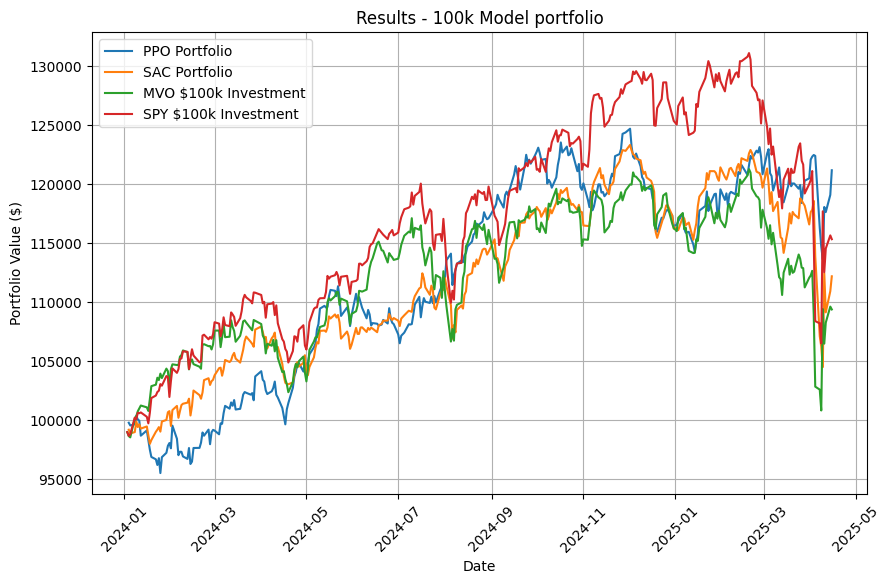

In [22]:
"""Portfolio graph"""
plt.figure(figsize=(10, 6))
plt.plot(date_history, portfolio_history, label='PPO Portfolio')
plt.plot(sac_date_history, sac_portfolio_history, label='SAC Portfolio')
plt.plot(test_data.index, mvo_portfolio_value, label='MVO $100k Investment')
plt.plot(test_data.index, spy_portfolio_value, label='SPY $100k Investment')

plt.title('Results - 100k Model portfolio​')
plt.xlabel('Date')
plt.ylabel('Portfolio Value ($)')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

In [23]:
#function to calculate Sharpe, drawdown, CAGR
def calculate_performance_metrics(returns, name="", annual_risk_free_rate=0.03, num_trading_days=252):
    daily_rf_rate = (1 + annual_risk_free_rate) ** (1 / num_trading_days) - 1
    excess_returns = returns - daily_rf_rate
    
    sharpe = (excess_returns.mean() / returns.std()) * np.sqrt(num_trading_days)
    cagr = (1 + returns.mean()) ** num_trading_days - 1
    drawdown = (returns.cumsum().expanding().max() - returns.cumsum()).max()
    
    return {
        f"{name} Sharpe Ratio": sharpe,
        f"{name} Max Drawdown": drawdown,
        f"{name} CAGR": cagr
    }

In [24]:
#function to calculate pure returns
def compute_return(portfolio, label):
    ret = (portfolio[-1] - portfolio[0]) / portfolio[0] * 100
    print(f"{label} returns: {ret:.3f}%")

In [25]:
#build a results df
results_df = pd.DataFrame({
    "Date": date_history,
    "Model_Portfolio": portfolio_history
})

results_df.set_index("Date", inplace=True)

spy_aligned = spy_portfolio_value.loc[results_df.index]
results_df["SPY_Portfolio"] = spy_aligned

mvo_aligned = mvo_portfolio_value.loc[results_df.index]
results_df["MVO_Portfolio"] = mvo_aligned

#calculate daily returns
results_df["Model_Returns"] = results_df["Model_Portfolio"].pct_change()
results_df["SPY_Returns"] = results_df["SPY_Portfolio"].pct_change()
results_df["MVO_Returns"] = results_df["MVO_Portfolio"].pct_change()

#calculate actual number of trading days
num_trading_days = results_df["Model_Returns"].dropna().shape[0]+1

sac_series = pd.Series(
    data=sac_portfolio_history,
    index=pd.to_datetime(sac_date_history),
    name="SAC_Portfolio",
)

#SAC was being diffucult:
#new safety line
results_df = results_df.drop(columns=["SAC_Portfolio"], errors="ignore")

#join by index
results_df = results_df.join(sac_series, how="left")

#Compute daily returns
results_df["SAC_Returns"] = results_df["SAC_Portfolio"].pct_change()

In [26]:
#calculate performance_metrics, export to table
ppo_sharpe = calculate_performance_metrics(results_df['Model_Returns'], name='PPO')
sac_sharpe = calculate_performance_metrics(results_df['SAC_Returns'], name='SAC')
mvo_sharpe= calculate_performance_metrics(results_df['MVO_Returns'], name='MVO')
spy_sharpe = calculate_performance_metrics(results_df['SPY_Portfolio'].pct_change(), name='SPY')

all_metrics = {**ppo_sharpe, **sac_sharpe, **mvo_sharpe, **spy_sharpe}
metrics_df = pd.DataFrame.from_dict(all_metrics, orient='index', columns=["Value"])

metrics_df = metrics_df.reset_index()
metrics_df[['Strategy', 'Metric']] = metrics_df['index'].str.extract(r'(\w+)\s(.+)')
metrics_df = metrics_df.drop(columns='index')


pivot_df = metrics_df.pivot(index='Strategy', columns='Metric', values='Value')
pivot_df = pivot_df[['Sharpe Ratio', 'Max Drawdown', 'CAGR']]  

pivot_df = pivot_df.reset_index()
pivot_df.columns.name = None
pivot_df = pivot_df.sort_values(by="Sharpe Ratio", ascending=False).reset_index(drop=True)
display(pivot_df)



,Strategy,Sharpe Ratio,Max Drawdown,CAGR
0,PPO,1.011094,0.088967,0.175157
1,SPY,0.604346,0.202302,0.149145
2,SAC,0.534390,0.160248,0.113499
3,MVO,0.395472,0.180615,0.099430


In [27]:
compute_return(portfolio_history, "PPO")
compute_return(sac_portfolio_history, "SAC")
compute_return(mvo_portfolio_value, "MVO")
compute_return(spy_portfolio_value, "SPY")

PPO returns: 21.429%
SAC returns: 13.096%
MVO returns: 10.493%
SPY returns: 16.501%


/var/folders/nn/k590rnyx4_g52hvjx7km2s8w0000gn/T/ipykernel_84056/1693200480.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ret = (portfolio[-1] - portfolio[0]) / portfolio[0] * 100
